In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame = True)

In [5]:
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split


In [11]:
np.random.seed(42)

#create the data

x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [14]:
#split the data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [16]:
model = Ridge()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.5758549611440126

In [20]:
from sklearn import svm

regr = svm.SVR()
regr.fit(x_train,y_train)

y_pred = regr.predict(x_test)

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

1.3320115421348784
-0.016485360107176605


/\ svm above was not usefull
 |

Using Linear regression

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

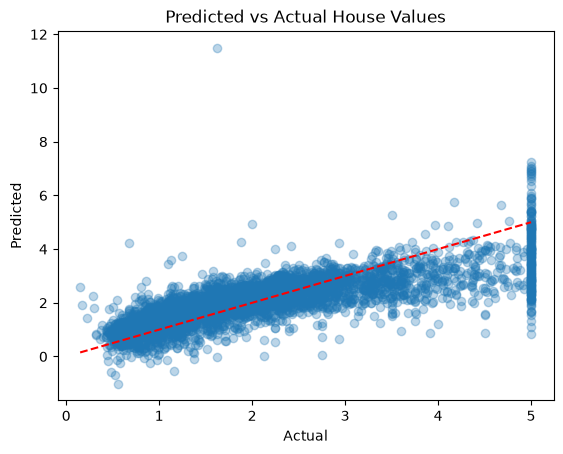

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual House Values")
plt.show()